# Q4 — Salary and Satisfaction Gaps by Gender and Education

**Question:** How do salary and satisfaction differ across gender and education levels?

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

# Load and clean - same cleaning decision made in the SQL phase:
# blank education values become the literal string 'None'
df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


### Median salary: gender x education

In [2]:
salary_gap = pd.pivot_table(df, values="salary_midpoint", index="gender",
                             columns="education", aggfunc="median")
salary_gap

education,Associates,Bachelors,High School,Masters,None,PhD
gender,,,,,,
Female,"95,500.00","53,000.00","53,000.00","53,000.00","53,000.00","57,750.00"
Male,"20,000.00","20,000.00","20,000.00","53,000.00","53,000.00","187,500.00"


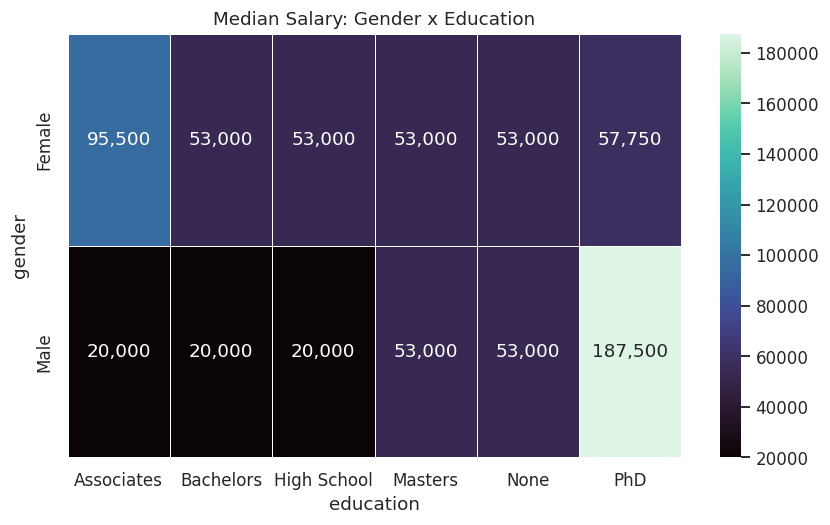

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(salary_gap, annot=True, fmt=",.0f", cmap="mako", linewidths=0.5, ax=ax)
ax.set_title("Median Salary: Gender x Education")
fig.savefig(OUT / "q4_salary_gender_education_heatmap.png", bbox_inches="tight")
plt.show()

### Mean composite satisfaction: gender x education

In [4]:
satisfaction_gap = pd.pivot_table(df, values="satisfaction_composite", index="gender",
                                   columns="education", aggfunc="mean")
satisfaction_gap

education,Associates,Bachelors,High School,Masters,None,PhD
gender,,,,,,
Female,6.00,5.08,4.50,5.10,5.33,7.42
Male,5.14,5.33,5.09,5.36,5.01,6.45


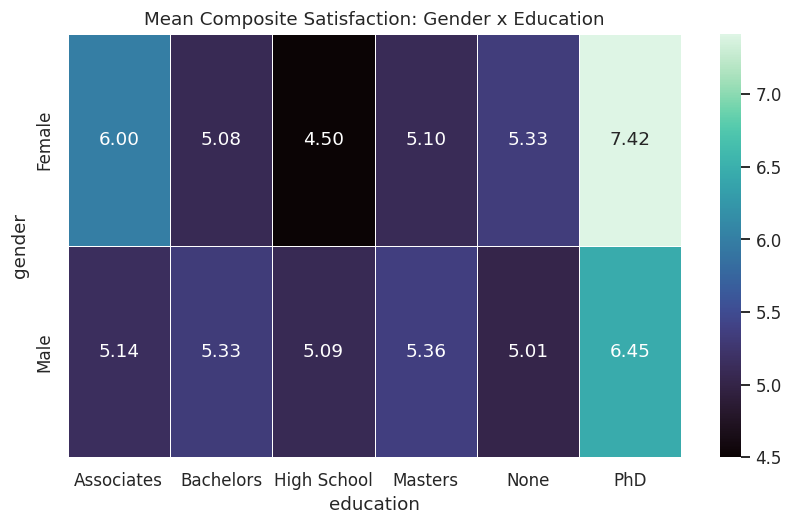

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(satisfaction_gap, annot=True, fmt=".2f", cmap="mako", linewidths=0.5, ax=ax)
ax.set_title("Mean Composite Satisfaction: Gender x Education")
fig.savefig(OUT / "q4_satisfaction_gender_education_heatmap.png", bbox_inches="tight")
plt.show()

**Takeaway:** Gaps are uneven and non-monotonic (e.g. male PhDs show a much higher median salary than female PhDs, but the reverse holds for satisfaction). Some cells have small sample sizes — worth flagging as a caveat rather than a clean trend.